In [17]:
import numpy as np
import matplotlib.pyplot as plt
from regpy.operators.convolution import ConvolutionOperator, GaussianBlur, ExponentialConvolution
from regpy.vecsps import UniformGridFcts
from regpy.solvers import TikhonovRegularizationSetting, RegularizationSetting, RegSolver
from regpy.solvers import DualityGapStopping
from regpy.solvers.linear.semismoothNewton import SemismoothNewton_bilateral, SemismoothNewton_nonneg, SemismoothNewtonAlphaGrid
from regpy.solvers.linear.tikhonov import TikhonovCG
from regpy.solvers.linear.primal_dual import PDHG
from regpy.solvers.linear.proximal_gradient import FISTA
import regpy.functionals as fct
from regpy.hilbert import L2
from regpy.stoprules import CountIterations
from comparison_plot import comparison_plot
import logging

# Generate a test image as exact solution

In [2]:
grid = UniformGridFcts((-1, 1, 256), (-1.5, 1, 256),dtype = float, periodic = True)
"""Space of real-valued functions on a uniform grid with rectangular pixels"""
X = grid.coords[0]; Y = grid.coords[1]
"""x and y coordinates."""
cross = 1.0*np.logical_or((abs(X)<0.01) * (abs(Y)<0.3),(abs(X)<0.3) * (abs(Y)<0.01)) 
rad = np.sqrt(X**2 + Y**2)
ring = 1.0*np.logical_and(rad>=0.9, rad<=0.925)
smallbox = (abs(X+0.55)<=0.05) * (abs(Y-0.55)<=0.05)
bubbles = (1.001+np.sin(50/(X+1.3)))*np.exp(-((Y+1.25)/0.1)**2)*(X>-0.8)*(X<0.8)

ramp = Y<=-1

objects = 50*(ring + 2.0*cross + 1.5*smallbox + 2*ramp -bubbles)
exact_sol = objects 


# Generate synthetic data with impulsive noise

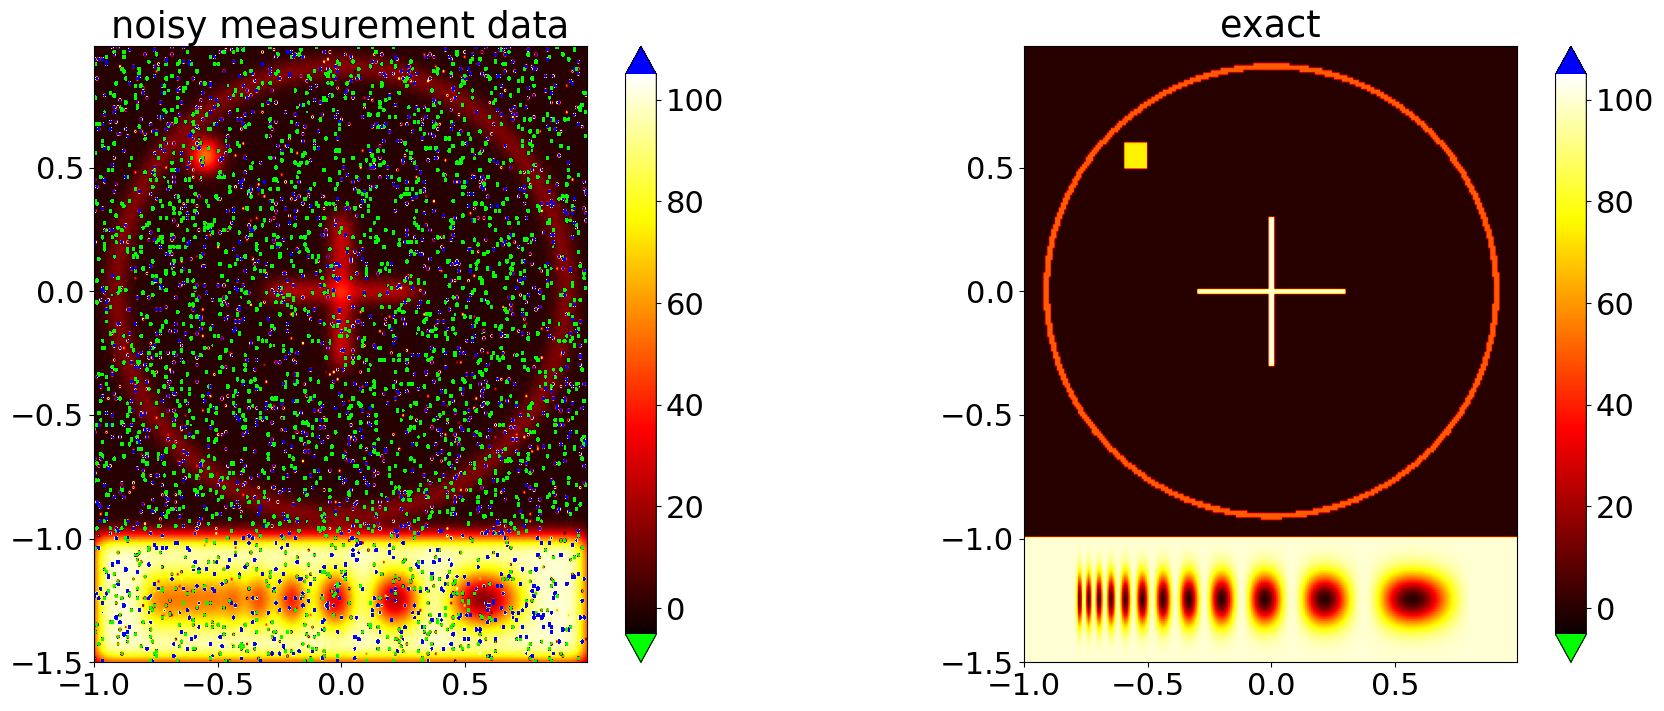

In [3]:
a=0.05
conv =  GaussianBlur(grid,a,pad_amount=((16,16),(16,16)))
"""Convolution operator \(f\mapsto h*f\) for the convolution kernel \(h(x)=\exp(-|x|_2^2/a^2)\)."""
blur = conv(exact_sol)
blur[blur<0] = 0.
data = blur.copy()
n,m=grid.shape
for j in range(64**2):
    nn = np.random.randint(n)
    mm = np.random.randint(m)
    data[nn,mm] =  np.random.randint(2000)-1000

comparison_plot(grid,exact_sol,data,title_left='noisy measurement data')

# Reconstruction with a quadratic data fidelity term

2024-07-07 12:10:14,899 INFO TikhonovCG           :: it.746 kappa=21.330145118776883 err/Tol rel X:9.8e-07/1.0e-06 
2024-07-07 12:10:14,900 INFO TikhonovCG           :: Solver converged after 746 iteration.


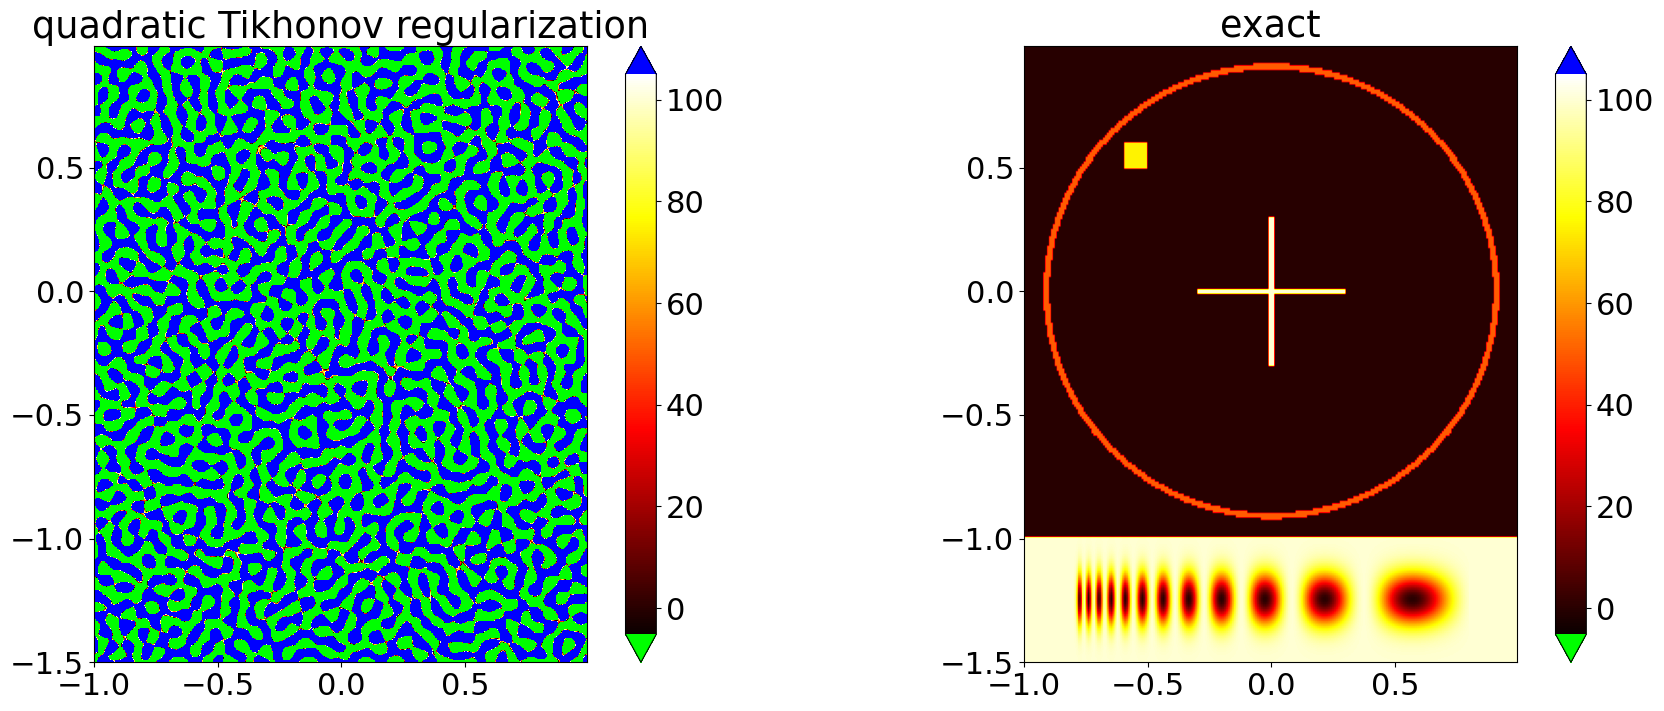

In [8]:
alpha = 1e-4
setting = RegularizationSetting(conv,L2,L2)
solver = TikhonovCG(setting=setting, data = data, regpar = alpha,reltolx=1e-6)
fal,_ = solver.run()

comparison_plot(grid,exact_sol,fal,title_left='quadratic Tikhonov regularization')

# setting with Huber data fidelity and quadratic penalty term
We now set up a generalized Tikhonov regularization setting
$$
\hat{f} \in \mathrm{argmin}_f\left[\frac{1}{\alpha}H_{\sigma}(Tf-g^{\mathrm{obs}})+\|f\|^2\right]    
$$
where the Huber data fidelity term $H_{\sigma}$ is quadratic on coordinates in $[-\sigma,\sigma]$ and $|\cdot|-\sigma/2$ for large coordinates.

We test three solvers for this setting:
- FISTA applied to the primal problem
- FISTA applied to the dual problem
- Primal-Dual Hybrid Gradient (Chambolle-Pock) method

In [22]:
sigma = 10.
Sdat = (1./sigma)*fct.Huber(grid,sigma=sigma)
huber_setting = TikhonovRegularizationSetting(conv,L2,Sdat,alpha,data_fid_shift=data)
dual_setting = huber_setting.dualSetting()


### FISTA applied to primal problem

2024-07-07 12:51:49,491 INFO FISTA                :: Setting up FISTA with convexity parameters mu_R=1.000e-04, mu_S=0.000e+00 and step length tau=1.006e+01.
 Expected linear convergence rate: 9.683e-01
2024-07-07 12:51:49,523 INFO DualityGapStopping   :: it. 0/400: duality gap=6.905e+07
2024-07-07 12:51:49,524 INFO DualityGapStopping   :: it. 0/400: duality gap=6.905e+07 (1.000e-03)
2024-07-07 12:51:49,566 INFO DualityGapStopping   :: it. 1/400: duality gap=5.015e+07 (1.000e-03)
2024-07-07 12:51:49,607 INFO DualityGapStopping   :: it. 2/400: duality gap=4.439e+07 (1.000e-03)
2024-07-07 12:51:49,644 INFO DualityGapStopping   :: it. 3/400: duality gap=4.049e+07 (1.000e-03)
2024-07-07 12:51:49,687 INFO DualityGapStopping   :: it. 4/400: duality gap=3.657e+07 (1.000e-03)
2024-07-07 12:51:49,720 INFO DualityGapStopping   :: it. 5/400: duality gap=2.886e+07 (1.000e-03)
2024-07-07 12:51:49,845 INFO DualityGapStopping   :: it. 6/400: duality gap=2.313e+07 (1.000e-03)
2024-07-07 12:51:49,916 I

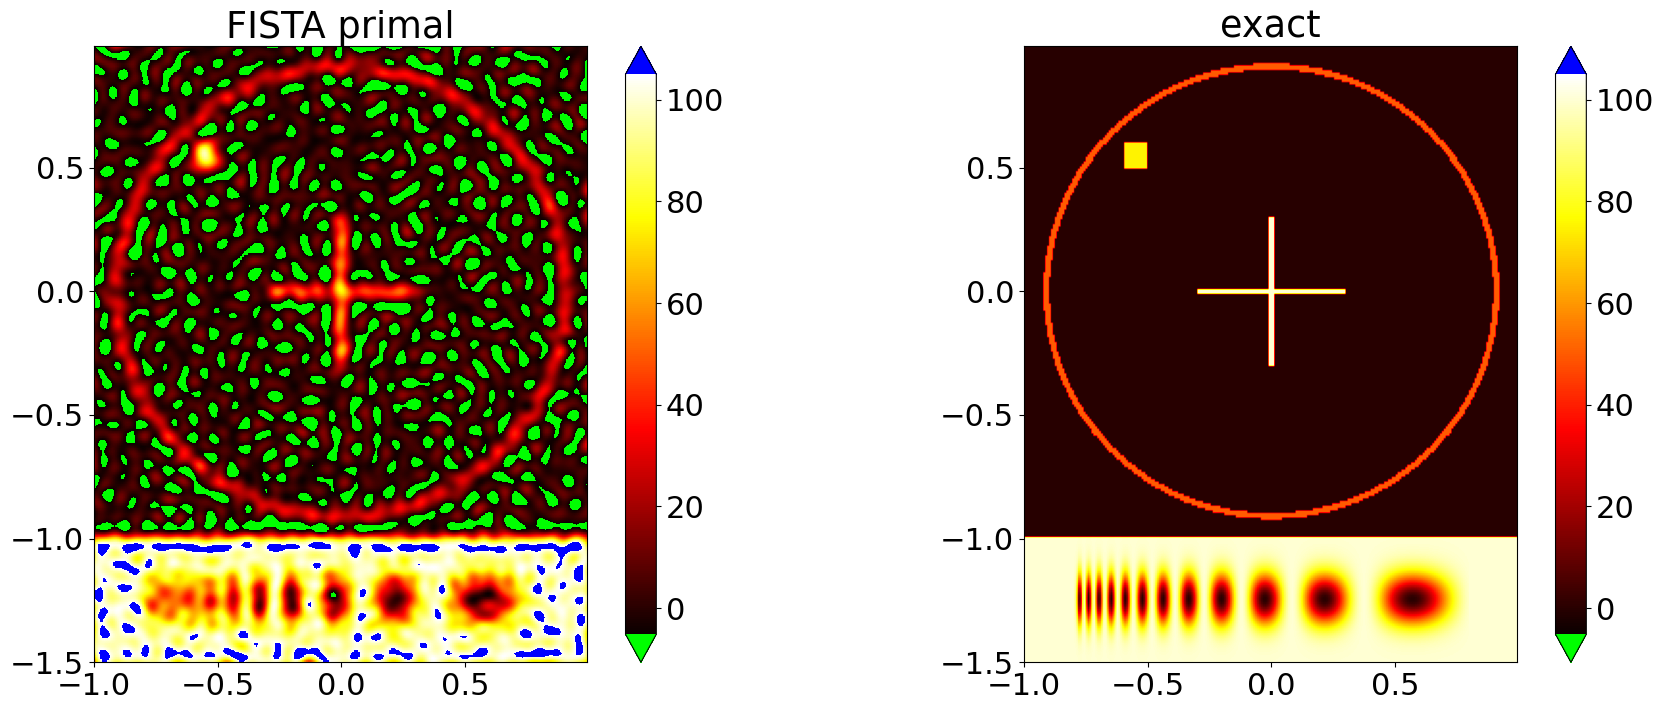

In [23]:
solverFISTA_primal = FISTA(huber_setting,logging_level=logging.DEBUG)
stop_FISTA_primal=DualityGapStopping(solverFISTA_primal,threshold = 1e-3, max_iter=400,logging_level=logging.INFO)
f_FISTA_primal, _= solverFISTA_primal.run(stoprule=stop_FISTA_primal)

comparison_plot(grid,exact_sol,f_FISTA_primal,title_left='FISTA primal')

### FISTA applied to the dual problem

2024-07-07 12:52:11,582 INFO FISTA                :: Setting up FISTA with convexity parameters mu_R=1.000e-03, mu_S=0.000e+00 and step length tau=1.014e+00.
 Expected linear convergence rate: 9.682e-01
2024-07-07 12:52:11,607 INFO DualityGapStopping   :: it. 0/400: duality gap=2.298e+02
2024-07-07 12:52:11,608 INFO DualityGapStopping   :: it. 0/400: duality gap=2.298e+02 (1.000e-03)
2024-07-07 12:52:11,644 INFO DualityGapStopping   :: it. 1/400: duality gap=1.601e+02 (1.000e-03)
2024-07-07 12:52:11,675 INFO DualityGapStopping   :: it. 2/400: duality gap=1.515e+02 (1.000e-03)
2024-07-07 12:52:11,727 INFO DualityGapStopping   :: it. 3/400: duality gap=1.429e+02 (1.000e-03)
2024-07-07 12:52:11,765 INFO DualityGapStopping   :: it. 4/400: duality gap=1.318e+02 (1.000e-03)
2024-07-07 12:52:11,799 INFO DualityGapStopping   :: it. 5/400: duality gap=1.174e+02 (1.000e-03)
2024-07-07 12:52:11,829 INFO DualityGapStopping   :: it. 6/400: duality gap=9.948e+01 (1.000e-03)
2024-07-07 12:52:11,863 I

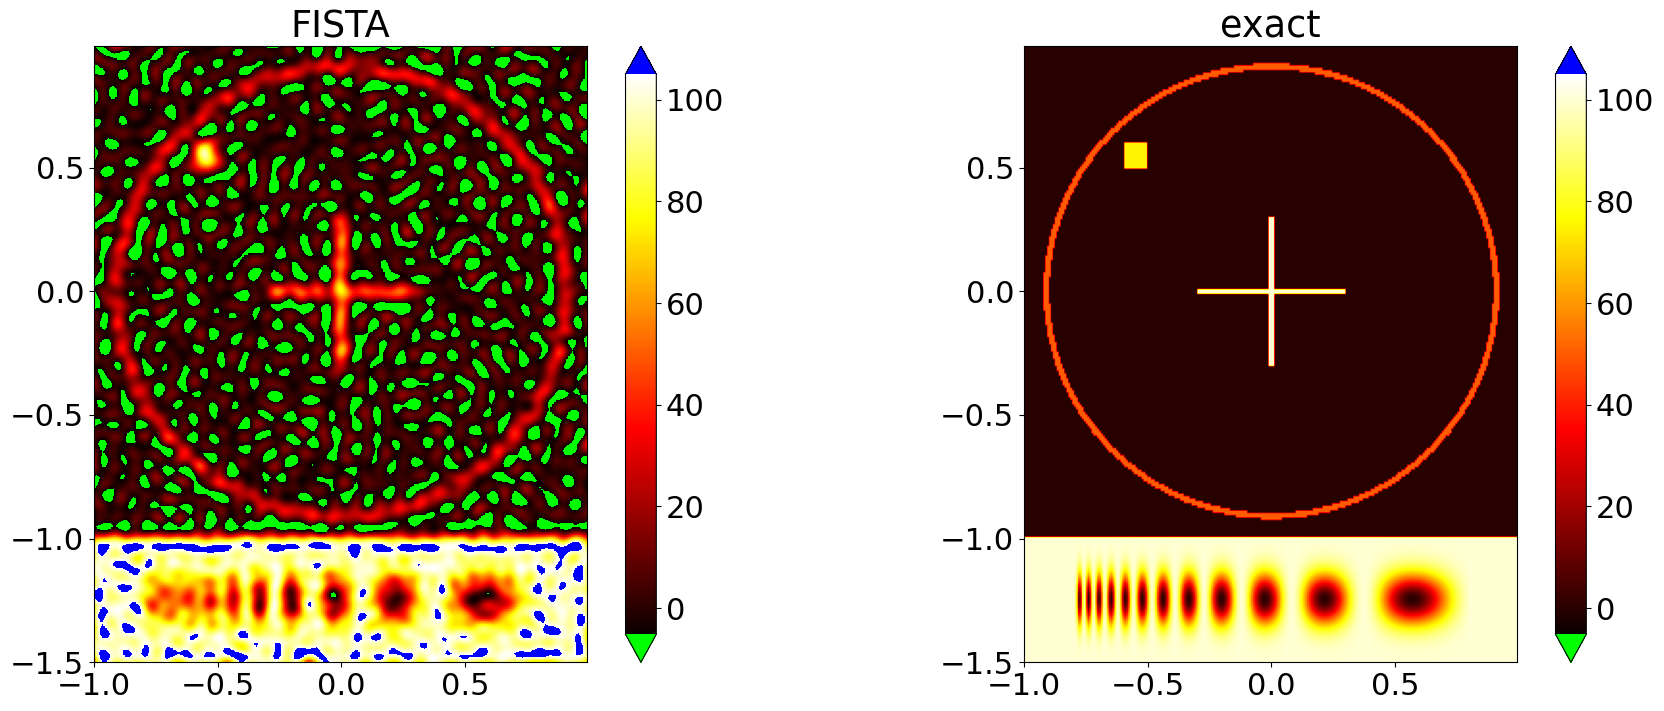

In [24]:
solverFISTA_dual = FISTA(dual_setting,logging_level=logging.DEBUG)
stop_FISTA_dual=DualityGapStopping(solverFISTA_dual,threshold = 1e-3, max_iter=400,logging_level=logging.INFO)
pFISTA_dual, Tstar_pFISTA_dual= solverFISTA_dual.run(stoprule=stop_FISTA_dual)

f_FISTA_dual = huber_setting.dualToPrimal(Tstar_pFISTA_dual,argumentIsOperatorImage=True)
comparison_plot(grid,exact_sol,f_FISTA_dual,title_left='FISTA')

### PDHG


2024-07-07 12:52:20,377 INFO PDHG                 :: Using accelerated version 2 with convexity parameters mu_R=1.000e+00, mu_S*=1.000e-03 and ||T||=9.968e-01.
 Expected linear convergence rate: 9.403e-01
2024-07-07 12:52:20,401 INFO DualityGapStopping   :: it. 0/400: duality gap=6.905e+07
2024-07-07 12:52:20,403 INFO DualityGapStopping   :: it. 0/400: duality gap=6.905e+07 (1.000e-03)
2024-07-07 12:52:20,441 INFO DualityGapStopping   :: it. 1/400: duality gap=3.298e+06 (1.000e-03)
2024-07-07 12:52:20,508 INFO DualityGapStopping   :: it. 2/400: duality gap=5.179e+05 (1.000e-03)
2024-07-07 12:52:20,543 INFO DualityGapStopping   :: it. 3/400: duality gap=1.171e+05 (1.000e-03)
2024-07-07 12:52:20,576 INFO DualityGapStopping   :: it. 4/400: duality gap=7.058e+04 (1.000e-03)
2024-07-07 12:52:20,615 INFO DualityGapStopping   :: it. 5/400: duality gap=4.499e+04 (1.000e-03)
2024-07-07 12:52:20,649 INFO DualityGapStopping   :: it. 6/400: duality gap=2.865e+04 (1.000e-03)
2024-07-07 12:52:20,697

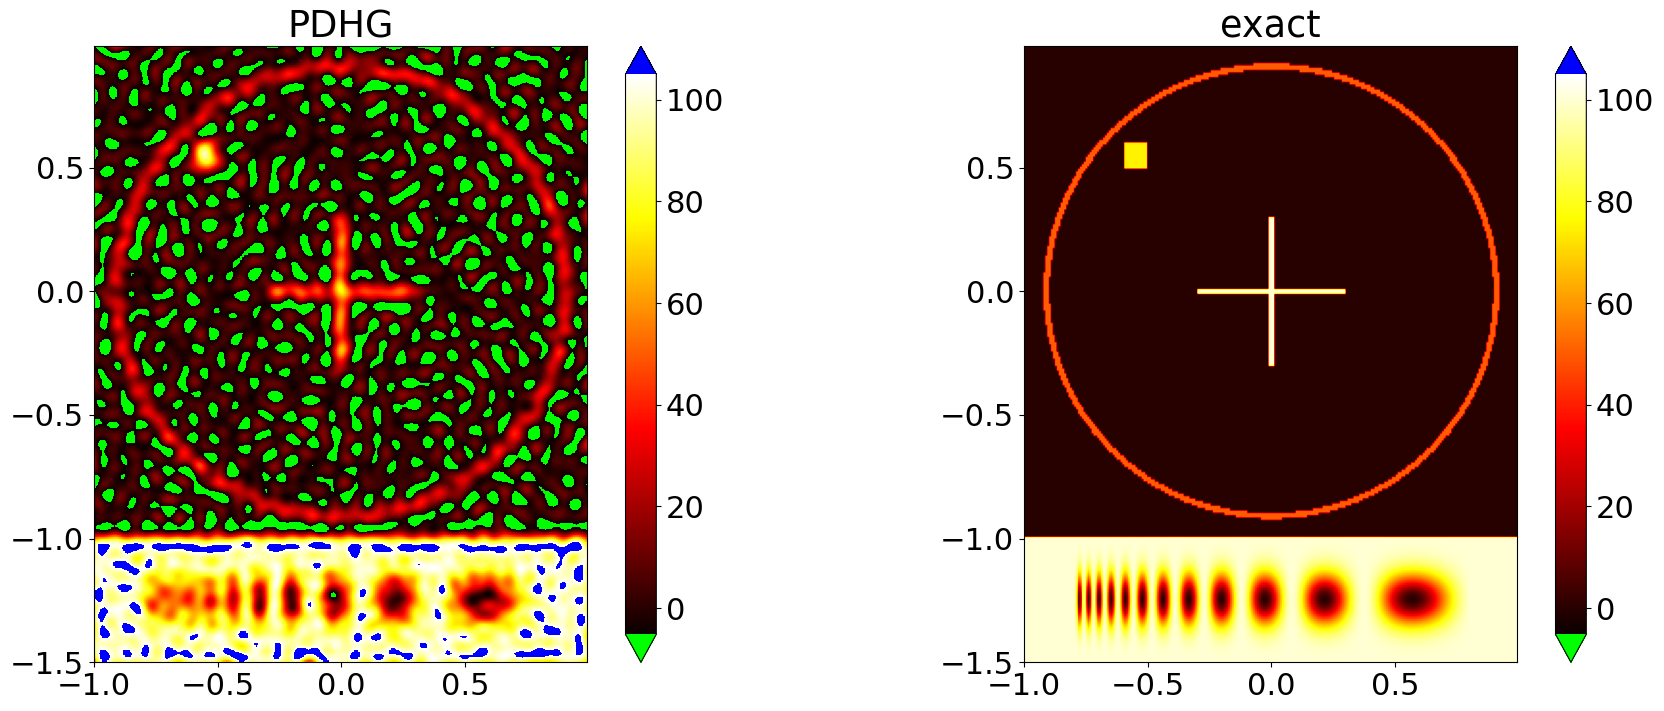

In [25]:
solverPDHG = PDHG(huber_setting,logging_level=logging.INFO)
stop_PDHG=DualityGapStopping(solverPDHG,threshold = 1e-3, max_iter=400,logging_level=logging.INFO)
f_PDHG, _= solverPDHG.run(stoprule=stop_PDHG)

comparison_plot(grid,exact_sol,f_PDHG,title_left='PDHG')

Text(0.5, 1.0, 'Huber data fid., quadratic penalty')

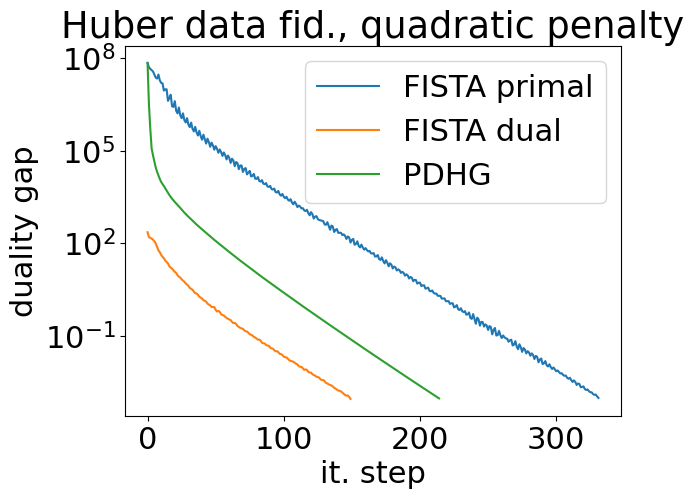

In [26]:
plt.semilogy(stop_FISTA_primal.gap_stat,label='FISTA primal')
plt.semilogy(stop_FISTA_dual.gap_stat,label='FISTA dual')
plt.semilogy(stop_PDHG.gap_stat,label='PDHG')
plt.legend()
plt.xlabel('it. step'); plt.ylabel('duality gap')
plt.title('Huber data fid., quadratic penalty')

# setting with Huber data fidelity and quadratic penalty term with bilateral constraints
We now set up a generalized Tikhonov regularization setting
$$
\hat{f} \in \mathrm{argmin}_{0\leq f\leq ub}\left[\frac{1}{\alpha}H_{\sigma}(Tf-g^{\mathrm{obs}})+\|f\|_{L^2}^2\right]    
$$
where the Huber data fidelity term $H_{\sigma}$ is quadratic on coordinates in $[-\sigma,\sigma]$ and $|\cdot|-\sigma/2$ for large coordinates.

We test three solvers for this setting:
- FISTA applied to the primal problem
- FISTA applied to the dual problem
- Primal-Dual Hybrid Gradient (Chambolle-Pock) method

In [27]:
Sfun 
Rfun = fct.Quadratic_(grid)
huber_setting = TikhonovRegularizationSetting(conv,Rfun,Sdat,alpha,data_fid_shift=data)
dual_setting = huber_setting.dualSetting()


NameError: name 'Sfun' is not defined